In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/student_performance.csv")
print(df.shape)
df.head()

(1000000, 6)


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [3]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000
unique,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,A
freq,NaN,NaN,NaN,NaN,NaN,548644
mean,500000.500000,15.029127,84.711046,5.985203,84.283845,NaN
std,288675.278932,6.899431,9.424143,1.956421,15.432969,NaN
min,1.000000,0.000000,50.000000,0.000000,9.400000,NaN
25%,250000.750000,10.300000,78.300000,4.700000,73.900000,NaN
50%,500000.500000,15.000000,85.000000,6.000000,87.500000,NaN
75%,750000.250000,19.700000,91.800000,7.300000,100.000000,NaN


In [4]:
missing_counts = df.isna().sum()
missing_nonzero = missing_counts[missing_counts > 0]
missing_nonzero

if len(missing_nonzero) == 0:
    print("No missing values found.")
else:
    plt.figure(figsize=(6, 3))
    missing_nonzero.plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

No missing values found.


In [5]:
df_clean = df.drop_duplicates().copy()

numeric_cols = df_clean.select_dtypes(include="number").columns
categorical_cols = df_clean.select_dtypes(exclude="number").columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    mode_vals = df_clean[col].mode(dropna=True)
    if len(mode_vals) > 0:
        df_clean[col] = df_clean[col].fillna(mode_vals[0])

df_clean.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [6]:
target = df_clean["grade"]
features = df_clean.drop(columns=["grade", "student_id"])

grade_order = ["D", "C", "B", "A"]
grade_cat = pd.Categorical(target, categories=grade_order, ordered=True)
grade_code = grade_cat.codes

df_clean = df_clean.assign(grade_code=grade_code)
df_clean[["grade", "grade_code"]].head()

,grade,grade_code
0,A,3
1,B,2
2,A,3
3,A,3
4,A,3


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled[:5]

array([[ 0.50306682,  1.15543228, -1.11693968,  0.88227753],
       [-0.1491612 , -0.49989141, -1.78141884, -0.02487179],
       [ 0.64800638,  0.16860469, -0.35023296,  1.01834992],
       [ 1.54663166, -1.53977424,  0.51870132,  1.01834992],
       [-0.23612494, -0.29828148,  0.46758754,  0.49997889]])

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["grade"] = target.values

df_pca.head()

,PC1,PC2,grade
0,0.975675,-1.609203,A
1,-0.125170,-0.910069,B
2,1.177404,-0.370157,A
3,1.817291,1.449406,A
4,0.187882,0.541225,A


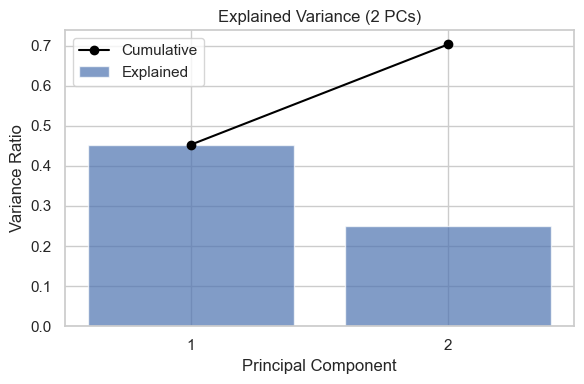

In [9]:
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(6, 4))
plt.bar([1, 2], explained, alpha=0.7, label="Explained")
plt.plot([1, 2], cum_explained, marker="o", color="black", label="Cumulative")
plt.xticks([1, 2])
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title("Explained Variance (2 PCs)")
plt.legend()
plt.tight_layout()
plt.show()

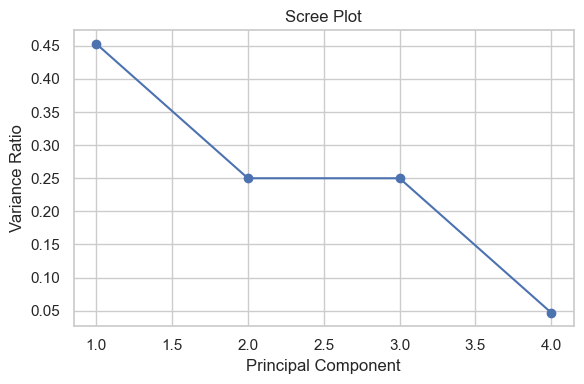

In [10]:
pca_full = PCA().fit(X_scaled)
full_explained = pca_full.explained_variance_ratio_

plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(full_explained) + 1),
    full_explained,
    marker="o",
    linestyle="-"
)
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title("Scree Plot")
plt.tight_layout()
plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_15808\2152577925.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Home\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


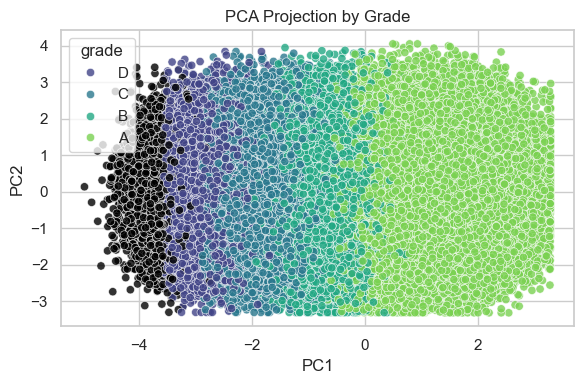

In [11]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="grade",
    hue_order=grade_order,
    palette="viridis",
    alpha=0.8
)
plt.title("PCA Projection by Grade")
plt.tight_layout()
plt.show()

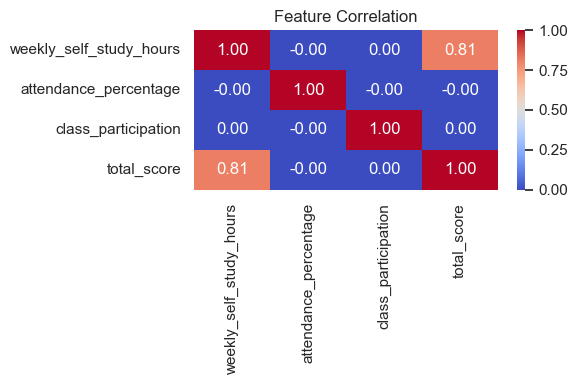

In [12]:
plt.figure(figsize=(6, 4))
corr = features.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

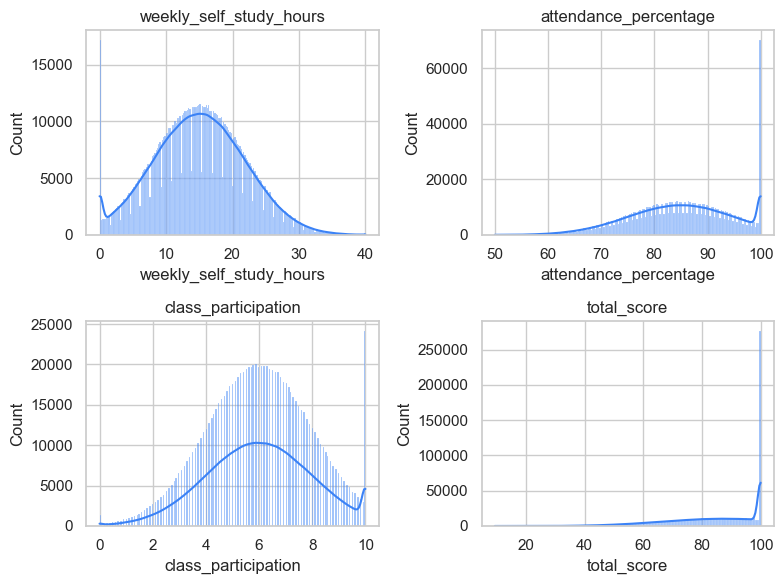

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()

for i, col in enumerate(features.columns[:4]):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color="#3b82f6")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features.columns,
    columns=["PC1", "PC2"]
)
loadings

,PC1,PC2
weekly_self_study_hours,0.707105,-0.001477
attendance_percentage,-0.001760,-0.705276
class_participation,0.001678,0.708929
total_score,0.707104,-0.001961
